<a href="https://colab.research.google.com/github/richards07-afk/Statistical-Theory/blob/main/SANTOS_FA13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

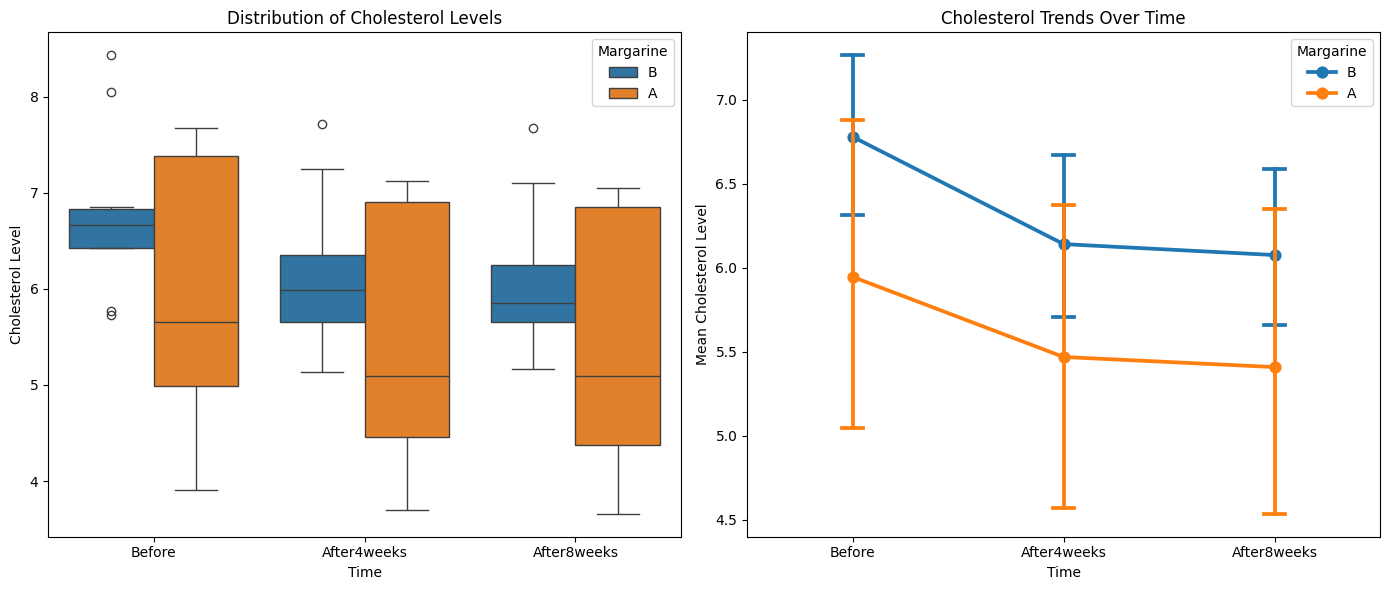

--- ANOVA Table ---
                         sum_sq    df         F    PR(>F)
C(Margarine)           6.979363   1.0  5.663479  0.021343
C(Time)                4.319544   2.0  1.752570  0.184237
C(Margarine):C(Time)   0.079991   2.0  0.032455  0.968088
Residual              59.152585  48.0       NaN       NaN

--- STATISTICAL DECISION ---
Interaction P-value is 0.9681. Fail to Reject the Null Hypothesis.
Conclusion: There is no significant difference in the cholesterol levels between the two brands of margarine over the three time points.


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'ID': list(range(1, 19)),
    'Before': [6.42, 6.76, 6.56, 4.8, 8.43, 7.49, 8.05, 5.05, 5.77, 3.91, 6.77, 6.44, 6.17, 7.67, 7.34, 6.85, 5.13, 5.73],
    'After4weeks': [5.83, 6.2, 5.83, 4.27, 7.71, 7.12, 7.25, 4.63, 5.31, 3.7, 6.15, 5.59, 5.56, 7.11, 6.84, 6.4, 4.52, 5.13],
    'After8weeks': [5.75, 6.13, 5.71, 4.15, 7.67, 7.05, 7.1, 4.67, 5.33, 3.66, 5.96, 5.64, 5.51, 6.96, 6.82, 6.29, 4.45, 5.17],
    'Margarine': ['B', 'B', 'B', 'A', 'B', 'A', 'B', 'A', 'B', 'A', 'B', 'B', 'A', 'A', 'A', 'B', 'A', 'B']
}

df = pd.DataFrame(data)

df_long = pd.melt(df, id_vars=['ID', 'Margarine'],
                  value_vars=['Before', 'After4weeks', 'After8weeks'],
                  var_name='Time', value_name='Cholesterol')

model = ols('Cholesterol ~ C(Margarine) * C(Time)', data=df_long).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_long, x='Time', y='Cholesterol', hue='Margarine')
plt.title('Distribution of Cholesterol Levels')
plt.ylabel('Cholesterol Level')

plt.subplot(1, 2, 2)
sns.pointplot(data=df_long, x='Time', y='Cholesterol', hue='Margarine', capsize=.1)
plt.title('Cholesterol Trends Over Time')
plt.ylabel('Mean Cholesterol Level')

plt.tight_layout()
plt.show()

print("--- ANOVA Table ---")
print(anova_table)

p_interaction = anova_table.loc['C(Margarine):C(Time)', 'PR(>F)']
alpha = 0.05

print("\n--- STATISTICAL DECISION ---")
if p_interaction > alpha:
    print(f"Interaction P-value is {p_interaction:.4f}. Fail to Reject the Null Hypothesis.")
    print("Conclusion: There is no significant difference in the cholesterol levels between the two brands of margarine over the three time points.")
else:
    print(f"Interaction P-value is {p_interaction:.4f}. Reject the Null Hypothesis.")
    print("Conclusion: There is a significant difference in how the two brands affected cholesterol levels over time.")